In [54]:
import numpy as np
import pandas as pd

data = pd.read_csv("titanic./train.csv")

print(data.head(10).to_markdown())

|    |   PassengerId |   Survived |   Pclass | Name                                                | Sex    |   Age |   SibSp |   Parch | Ticket           |    Fare | Cabin   | Embarked   |
|---:|--------------:|-----------:|---------:|:----------------------------------------------------|:-------|------:|--------:|--------:|:-----------------|--------:|:--------|:-----------|
|  0 |             1 |          0 |        3 | Braund, Mr. Owen Harris                             | male   |    22 |       1 |       0 | A/5 21171        |  7.25   | nan     | S          |
|  1 |             2 |          1 |        1 | Cumings, Mrs. John Bradley (Florence Briggs Thayer) | female |    38 |       1 |       0 | PC 17599         | 71.2833 | C85     | C          |
|  2 |             3 |          1 |        3 | Heikkinen, Miss. Laina                              | female |    26 |       0 |       0 | STON/O2. 3101282 |  7.925  | nan     | S          |
|  3 |             4 |          1 |        1 | Fut

In [55]:
data.shape

(891, 12)

In [56]:
data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [57]:
data["Age"].min()

0.42

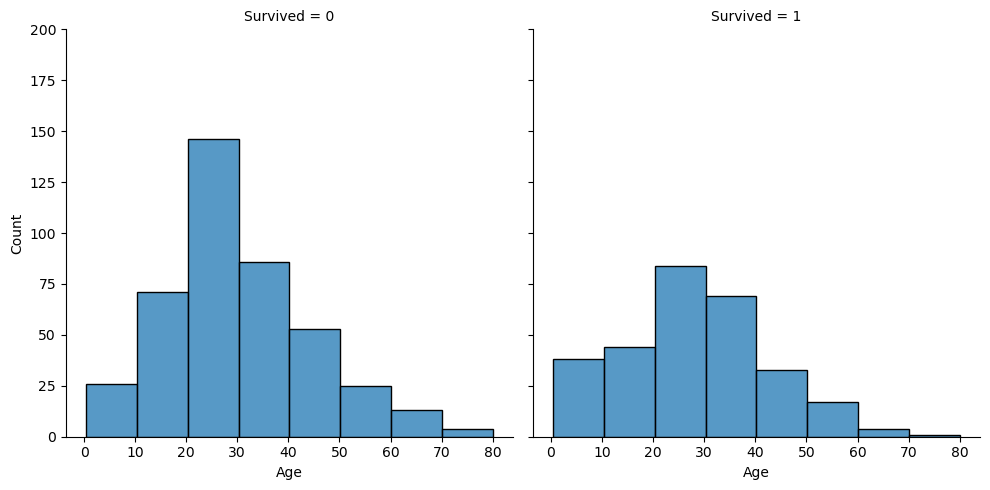

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.displot(data, x="Age", col="Survived", binwidth=10, height=5)
plt.ylim([0, 200])

data["Age"].fillna(data["Age"].mean(), inplace=True)
# data["Cabin"].fillna("outside", inplace=True)
data["Age_cut"] = pd.qcut(data["Age"], 8, duplicates="drop")

In [59]:
data.groupby("Age_cut", as_index=False)["Survived"].mean()

/tmp/ipykernel_26033/557738899.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby("Age_cut", as_index=False)["Survived"].mean()


,Age_cut,Survived
0,"(0.419, 17.0]",0.539823
1,"(17.0, 22.0]",0.313559
2,"(22.0, 27.0]",0.405660
3,"(27.0, 29.699]",0.299107
4,"(29.699, 35.0]",0.451327
5,"(35.0, 45.0]",0.394737
6,"(45.0, 80.0]",0.368932


In [60]:
survived = data[data["Survived"] == 1]
died = data[data["Survived"] == 0]
print(len(survived), "survived")
print(len(died), "died")

342 survived
549 died


In [61]:
data["Cabin"].fillna("O", inplace=True)

In [62]:
data["Embarked"] = data["Embarked"].fillna(data["Embarked"].mode()[0])

In [63]:
data.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
Age_cut        0
dtype: int64

In [64]:
data["Family_size"] = data["SibSp"] + data["Parch"]

In [65]:
data["Family_size"].max()

10

In [66]:
data.groupby("Family_size")["Survived"].mean()

Family_size
0     0.303538
1     0.552795
2     0.578431
3     0.724138
4     0.200000
5     0.136364
6     0.333333
7     0.000000
10    0.000000
Name: Survived, dtype: float64

In [67]:
htype = data["Name"].str.split(",")
data["passenger_type"] = htype.apply(lambda x: x[1].split(".")[0].strip())

In [68]:
title_map = {
    "Capt": "Officer",
    "Col": "Officer",
    "Major": "Officer",
    "Dr": "Officer",
    "Rev": "Officer",

    "Don": "Royalty",
    "Sir": "Royalty",
    "Jonkheer": "Royalty",
    "Lady": "Royalty",
    "the Countess": "Royalty",

    "Mr": "Mr",
    "Mrs": "Mrs",
    "Miss": "Miss",
    "Master": "Master",
    "Mlle": "Miss",
    "Ms": "Miss",
    "Mme": "Mrs"
}
data["passenger_type_grouped"] = data["passenger_type"].map(title_map)
data["passenger_type_grouped"].isna().sum()
data.groupby("passenger_type_grouped")["Survived"].agg(["count", "mean"])



,count,mean
passenger_type_grouped,,
Master,40,0.575000
Miss,185,0.702703
Mr,517,0.156673
Mrs,126,0.793651
Officer,18,0.277778
Royalty,5,0.600000


In [69]:
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    train_test_split,
    learning_curve,
)
from sklearn.pipeline import Pipeline

from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import joblib


def candidate_models():

    return [
        (
            "logreg",
            LogisticRegression(max_iter=1000),
            {"model__C": [0.1, 1.0]},
        ),
        (
            "knn",
            KNeighborsClassifier(),
            {"model__n_neighbors": [5, 15], "model__weights": ["uniform"]},
        ),
        (
            "svm",
            SVC(),
            {"model__C": [1.0], "model__gamma": ["scale"]},
        ),
        (
            "rf",
            RandomForestClassifier(random_state=42, n_jobs=-1),
            {"model__n_estimators": [200], "model__max_depth": [None, 20]},
        ),
        (
            "gb",
            GradientBoostingClassifier(random_state=42),
            {"model__n_estimators": [100, 200], "model__learning_rate": [0.1]},
        ),
    ]


def main():
    print("Loading data...")
    X = data.drop(columns="Survived")
    y = data["Survived"]
    print("\nSplitting data (80/20)...")
    X_train, X_holdout, y_train, y_holdout = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y,
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    best = None
    best_name = None
    best_score = -np.inf

    print("\n" + "=" * 60)
    print("STARTING GRID SEARCH (5-fold CV)")
    print("=" * 60)

    numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
    categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

    binary_cols = [c for c in numeric_cols if X[c].nunique() == 2]
    numeric_cols = [c for c in numeric_cols if c not in binary_cols]

    pre = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_cols),
            ("bin", "passthrough", binary_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )

    for name, model, grid in candidate_models():
        print(f"\n[{name.upper()}] Grid search starting...")
        pipe = Pipeline([("pre", pre), ("model", model)])

        gs = GridSearchCV(pipe, grid, cv=cv, scoring="accuracy", n_jobs=-1, verbose=1)

        gs.fit(X_train, y_train)

        print(f"[{name.upper()}] Best CV score: {gs.best_score_:.4f}")
        print(f"[{name.upper()}] Best params: {gs.best_params_}")

        if gs.best_score_ > best_score:
            best_score = gs.best_score_
            best = gs.best_estimator_
            best_name = name

    print("\n" + "=" * 60)
    print("GRID SEARCH COMPLETE")
    print("=" * 60)

    print(f"\nBest model: {best_name.upper()}")
    print(f"Best CV accuracy: {best_score:.4f}")

    print("\nSaving model and results...")
    joblib.dump(best, "bestmodel.pkl")


if __name__ == "__main__":
    main()

Loading data...

Splitting data (80/20)...

STARTING GRID SEARCH (5-fold CV)

[LOGREG] Grid search starting...
Fitting 5 folds for each of 2 candidates, totalling 10 fits
[LOGREG] Best CV score: 0.8287
[LOGREG] Best params: {'model__C': 1.0}

[KNN] Grid search starting...
Fitting 5 folds for each of 2 candidates, totalling 10 fits
[KNN] Best CV score: 0.8160
[KNN] Best params: {'model__n_neighbors': 15, 'model__weights': 'uniform'}

[SVM] Grid search starting...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
[SVM] Best CV score: 0.8343
[SVM] Best params: {'model__C': 1.0, 'model__gamma': 'scale'}

[RF] Grid search starting...
Fitting 5 folds for each of 2 candidates, totalling 10 fits
[RF] Best CV score: 0.8329
[RF] Best params: {'model__max_depth': 20, 'model__n_estimators': 200}

[GB] Grid search starting...
Fitting 5 folds for each of 2 candidates, totalling 10 fits
[GB] Best CV score: 0.8272
[GB] Best params: {'model__learning_rate': 0.1, 'model__n_estimators': 200}

GR